# Notebook 05: Personalised Intervention Decision Support

This notebook converts the complete local SHAP explanation from Notebook 04 into mentor facing intervention options.

### Locked intervention design

- All 24 local SHAP factors are retained.
- Every feature is mapped to one of five controlled intervention categories.
- Positive SHAP values are treated as evidence supporting an intervention option because they push the model toward the at risk class.
- Negative SHAP values remain in the full explanation but do not add intervention support.
- Factors mapped to the same intervention are aggregated.
- The resulting intervention categories are ranked for mentor review.
- The system **does not assign interventions**.
- The mentor or academic advisor may select, combine, modify, or reject any proposed option.

The five intervention categories are:

1. Tutoring and academic support
2. Attendance support
3. Moodle engagement support
4. Workload adjustment
5. Counselling or advisor referral

## 1. Imports and paths

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

CURRENT_DIR = Path.cwd()
PROJECT_DIR = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
SHAP_DIR = PROJECT_DIR / "results" / "explainability"
OUTPUT_DIR = PROJECT_DIR / "results" / "interventions"
FIGURES_DIR = PROJECT_DIR / "results" / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 2. Load all 24 local SHAP factors

In [2]:
SHAP_FILE = SHAP_DIR / "at_risk_all_24_shap_factors.csv"
factors = pd.read_csv(SHAP_FILE)

required = {
    "case_id",
    "predicted_risk_probability",
    "feature",
    "raw_value",
    "shap_value",
}

missing = required - set(factors.columns)
if missing:
    raise KeyError(f"Missing columns: {sorted(missing)}")

counts = factors.groupby("case_id")["feature"].nunique()
assert counts.eq(24).all()

print("Predicted at risk students:", factors["case_id"].nunique())
print("Factors per student:", int(counts.iloc[0]))
print("Total rows:", len(factors))

Predicted at risk students: 225
Factors per student: 24
Total rows: 5400


## 3. Locked mapping from all 24 predictors to the intervention library

Every predictor has exactly one controlled intervention mapping.

The mapping does not imply that the feature itself is directly changed by the intervention. Historical and contextual factors can still provide evidence that academic support, workload review, or advisor involvement should be considered.

In [3]:
FEATURE_TO_INTERVENTION = {
    "registered_course_count": "Workload adjustment",
    "registered_credits": "Workload adjustment",
    "repeated_course_count_current": "Workload adjustment",
    "enrolled_course_count": "Workload adjustment",

    "previous_failed_course_count": "Tutoring and academic support",
    "previous_repeated_course_count": "Tutoring and academic support",
    "credits_earned_ratio": "Tutoring and academic support",
    "previous_term_gpa_ordinal": "Tutoring and academic support",
    "previous_cgpa_ordinal": "Tutoring and academic support",
    "assessment_interaction_events_ordinal": "Tutoring and academic support",

    "attendance_rate": "Attendance support",
    "absence_count": "Attendance support",

    "accessed_course_count": "Moodle engagement support",
    "course_access_rate": "Moodle engagement support",
    "total_course_event_clicks": "Moodle engagement support",
    "active_days_numeric": "Moodle engagement support",
    "active_days_rate": "Moodle engagement support",
    "zero_activity_days": "Moodle engagement support",
    "largest_inactivity_days": "Moodle engagement support",
    "learning_material_events_ordinal": "Moodle engagement support",

    "previous_withdrawn_course_count": "Counselling or advisor referral",
    "programme_or_school": "Counselling or advisor referral",
    "year_level": "Counselling or advisor referral",
    "previous_academic_standing": "Counselling or advisor referral",
}

unmapped = sorted(set(factors["feature"]) - set(FEATURE_TO_INTERVENTION))
if unmapped:
    raise ValueError(f"Unmapped features: {unmapped}")

df = pd.DataFrame(list(FEATURE_TO_INTERVENTION.items()), columns=["Feature", "Intervention"])
df_sorted = df.sort_values(["Intervention", "Feature"]).reset_index(drop=True)
df_sorted   # last line of the cell → renders as an HTML table


,Feature,Intervention
0,absence_count,Attendance support
1,attendance_rate,Attendance support
2,previous_academic_standing,Counselling or advisor referral
3,previous_withdrawn_course_count,Counselling or advisor referral
4,programme_or_school,Counselling or advisor referral
5,year_level,Counselling or advisor referral
6,accessed_course_count,Moodle engagement support
7,active_days_numeric,Moodle engagement support
8,active_days_rate,Moodle engagement support
9,course_access_rate,Moodle engagement support


## 4. Identify positive SHAP factors and calculate each factor's share

The complete 24 factor explanation is preserved.

For each student:

- `positive_risk_contribution = True` when the SHAP value is greater than zero,
- `positive_shap_value` keeps the positive contribution and replaces negative values with zero,
- positive factors are ranked from strongest to weakest,
- each positive factor is expressed as a percentage of that student's **total positive SHAP contribution**.

A negative SHAP factor therefore has a factor share of 0%.

This percentage describes the share of the student's positive model explanation attributable to that factor. It is not a probability of risk or intervention success.

In [4]:
mapped_factors = factors.copy()

mapped_factors["intervention"] = (
    mapped_factors["feature"]
    .map(FEATURE_TO_INTERVENTION)
)

mapped_factors["positive_risk_contribution"] = (
    mapped_factors["shap_value"] > 0
)

mapped_factors["positive_shap_value"] = (
    mapped_factors["shap_value"]
    .clip(lower=0)
)

student_total_positive_shap = (
    mapped_factors
    .groupby("case_id")[
        "positive_shap_value"
    ]
    .transform("sum")
)

mapped_factors[
    "positive_shap_factor_share_pct"
] = (
    mapped_factors["positive_shap_value"]
    .div(
        student_total_positive_shap.where(
            student_total_positive_shap > 0
        )
    )
    .fillna(0)
    .mul(100)
)

mapped_factors["positive_factor_rank"] = (
    mapped_factors[
        mapped_factors[
            "positive_risk_contribution"
        ]
    ]
    .groupby("case_id")[
        "shap_value"
    ]
    .rank(
        method="first",
        ascending=False,
    )
)

print("All 24 factors mapped for every student.")

factor_share_check = (
    mapped_factors
    .groupby("case_id")[
        "positive_shap_factor_share_pct"
    ]
    .sum()
)

print(
    "Mean positive factor share total:",
    round(
        factor_share_check.mean(),
        4,
    ),
)

print(
    "Expected total per student: 100%"
)

All 24 factors mapped for every student.
Mean positive factor share total: 100.0
Expected total per student: 100%


## 5. Aggregate positive SHAP evidence by intervention

Each positive factor already has an individual factor share.

Factors mapped to the same intervention category are then combined.

In [5]:
intervention_summary = (
    mapped_factors
    .groupby(
        [
            "case_id",
            "predicted_risk_probability",
            "intervention",
        ],
        as_index=False,
    )
    .agg(
        intervention_support_score=(
            "positive_shap_value",
            "sum",
        ),
        intervention_support_share_pct=(
            "positive_shap_factor_share_pct",
            "sum",
        ),
        supporting_positive_factor_count=(
            "positive_risk_contribution",
            "sum",
        ),
        all_mapped_factor_count=(
            "feature",
            "count",
        ),
    )
)

intervention_summary = (
    intervention_summary
    .sort_values(
        [
            "case_id",
            "intervention_support_share_pct",
        ],
        ascending=[
            True,
            False,
        ],
    )
)

intervention_summary[
    "proposed_option_rank"
] = (
    intervention_summary
    .groupby("case_id")
    .cumcount()
    + 1
)

share_check = (
    intervention_summary
    .groupby("case_id")[
        "intervention_support_share_pct"
    ]
    .sum()
)

print(
    "Mean intervention support share total:",
    round(
        share_check.mean(),
        4,
    ),
)

print(
    "Expected total per student: 100%"
)

Mean intervention support share total: 100.0
Expected total per student: 100%


## 6. Build proposed intervention options for mentor review

Only categories with a positive support score are proposed.

A student may have one, several, or all five proposed categories.

This does **not** mean the student must receive every proposed intervention. The final decision remains with the mentor.

In [6]:
positive_options = intervention_summary[
    intervention_summary["intervention_support_score"] > 0
].copy()

positive_factor_lists = (
    mapped_factors[mapped_factors["positive_risk_contribution"]]
    .groupby(["case_id", "intervention"])["feature"]
    .apply(lambda x: " | ".join(x.astype(str)))
    .rename("supporting_positive_factors")
    .reset_index()
)

positive_options = positive_options.merge(
    positive_factor_lists,
    on=["case_id", "intervention"],
    how="left",
)

plan_rows = []

for case_id, group in positive_options.groupby("case_id"):
    group = group.sort_values("proposed_option_rank")

    plan_rows.append({
        "case_id": case_id,
        "predicted_risk_probability": float(
            group["predicted_risk_probability"].iloc[0]
        ),
        "highest_priority_proposed_intervention": group["intervention"].iloc[0],
        "proposed_intervention_count": len(group),
        "proposed_interventions": " | ".join(group["intervention"]),
        "mentor_decision_status": "Pending mentor review",
    })

mentor_options = pd.DataFrame(plan_rows)

print("Students with proposed options:", len(mentor_options))
print("Automatic final intervention decisions:", 0)

Students with proposed options: 225
Automatic final intervention decisions: 0


## 7. Display one anonymised sample intervention plan

One anonymised case is displayed only to demonstrate how the decision support output would appear to a mentor.

The sample shows:

- calibrated predicted risk probability,
- ranked proposed intervention options,
- intervention support share,
- supporting positive SHAP factors,
- mentor decision status.

The proposed options are **not automatic assignments**. The mentor may select, combine, modify, or reject them.

In [7]:
sample_case_id = (
    mentor_options
    .sort_values("case_id")["case_id"]
    .iloc[11]
)

sample_student = mentor_options[
    mentor_options["case_id"] == sample_case_id
].iloc[0]

sample_plan = (
    positive_options[
        positive_options["case_id"] == sample_case_id
    ][
        [
            "proposed_option_rank",
            "intervention",
            "intervention_support_share_pct",
            "supporting_positive_factors",
        ]
    ]
    .sort_values("proposed_option_rank")
    .rename(
        columns={
            "proposed_option_rank": "rank",
            "intervention": "proposed_intervention",
            "intervention_support_share_pct": "support_share_pct",
            "supporting_positive_factors": "supporting_factors",
        }
    )
)

print("ANONYMISED SAMPLE INTERVENTION PLAN")
print("-----------------------------------")
print("Case ID:", sample_case_id)
print(
    "Predicted risk probability:",
    f"{sample_student['predicted_risk_probability']:.2%}",
)
print(
    "Mentor decision status:",
    sample_student["mentor_decision_status"],
)
print()
print(
    "These are proposed options for mentor review, "
    "not automatically assigned interventions."
)

display(
    sample_plan.style.format(
        {"support_share_pct": "{:.2f}%"}
    )
)

ANONYMISED SAMPLE INTERVENTION PLAN
-----------------------------------
Case ID: TEST_CASE_0039
Predicted risk probability: 87.55%
Mentor decision status: Pending mentor review

These are proposed options for mentor review, not automatically assigned interventions.


,rank,proposed_intervention,support_share_pct,supporting_factors
51,1,Tutoring and academic support,85.88%,previous_failed_course_count | previous_repeated_course_count | credits_earned_ratio | previous_term_gpa_ordinal | previous_cgpa_ordinal
52,2,Counselling or advisor referral,8.62%,programme_or_school | year_level | previous_academic_standing
53,3,Moodle engagement support,2.63%,accessed_course_count | course_access_rate | total_course_event_clicks | active_days_rate | zero_activity_days | largest_inactivity_days | active_days_numeric
54,4,Workload adjustment,2.00%,registered_course_count | enrolled_course_count
55,5,Attendance support,0.87%,attendance_rate


## 8. Intervention distribution

The figure shows how many students have positive SHAP evidence for each intervention category.

The count represents **proposed decision support options**, not assigned interventions.

,intervention,student_count
0,Tutoring and academic support,225
1,Workload adjustment,220
2,Counselling or advisor referral,209
3,Moodle engagement support,184
4,Attendance support,158


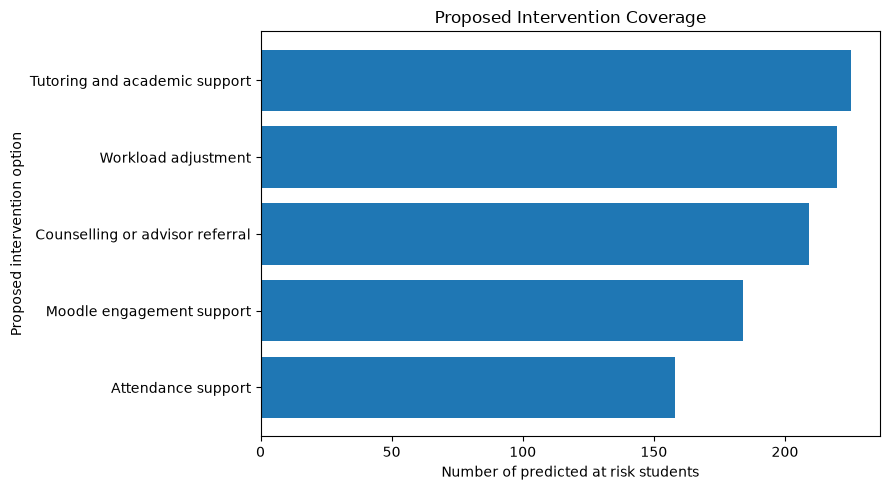

Saved: c:\Users\israa.tajaldin\OneDrive - Bahrain Polytechnic\Group Group IT9099 - Israa Tajaldin - General\04_Project_Notebooks\results\figures\proposed_intervention_distribution.png


In [8]:
distribution = (
    positive_options["intervention"]
    .value_counts()
    .rename_axis("intervention")
    .reset_index(name="student_count")
)

display(distribution)

plot_data = distribution.sort_values("student_count", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(plot_data["intervention"], plot_data["student_count"])
plt.xlabel("Number of predicted at risk students")
plt.ylabel("Proposed intervention option")
plt.title("Proposed Intervention Coverage")
plt.tight_layout()

FIGURE_FILE = FIGURES_DIR / "proposed_intervention_distribution.png"
plt.savefig(FIGURE_FILE, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", FIGURE_FILE)

## 9. Save complete intervention evidence and mentor facing outputs

The main detailed CSV keeps **all 24 factors for every predicted at risk student**, together with:

- predicted risk probability,
- feature,
- raw value,
- SHAP value,
- mapped intervention,
- whether the factor positively supports risk,
- positive SHAP value,
- positive factor rank,
- **positive SHAP factor share percentage**.

The intervention summary separately stores the aggregated support score and support share percentage for each intervention category.

In [9]:
ALL_FACTOR_FILE = OUTPUT_DIR / "all_24_factors_with_interventions.csv"
SUMMARY_FILE = OUTPUT_DIR / "intervention_support_summary.csv"
OPTION_FILE = OUTPUT_DIR / "mentor_proposed_intervention_options.csv"
AGENT_FILE = OUTPUT_DIR / "mentor_proposed_intervention_options.jsonl"

mapped_factors.to_csv(ALL_FACTOR_FILE, index=False)
positive_options.to_csv(SUMMARY_FILE, index=False)
mentor_options.to_csv(OPTION_FILE, index=False)

with open(AGENT_FILE, "w", encoding="utf-8") as file:
    for _, student in mentor_options.iterrows():
        case_id = student["case_id"]

        options = positive_options[
            positive_options["case_id"] == case_id
        ].sort_values("proposed_option_rank")

        record = {
            "case_id": case_id,
            "predicted_risk_probability": float(
                student["predicted_risk_probability"]
            ),
            "mentor_decision_status": "Pending mentor review",
            "proposed_interventions": [
                {
                    "rank": int(row["proposed_option_rank"]),
                    "intervention": row["intervention"],
                    "support_score": float(row["intervention_support_score"]),
                    "support_share_pct": float(
                        row["intervention_support_share_pct"]
                    ),
                    "supporting_positive_factors": (
                        row["supporting_positive_factors"].split(" | ")
                    ),
                }
                for _, row in options.iterrows()
            ],
        }

        file.write(json.dumps(record, default=str) + "\n")

print("Saved:", ALL_FACTOR_FILE)
print("Saved:", SUMMARY_FILE)
print("Saved:", OPTION_FILE)
print("Saved:", AGENT_FILE)

Saved: c:\Users\israa.tajaldin\OneDrive - Bahrain Polytechnic\Group Group IT9099 - Israa Tajaldin - General\04_Project_Notebooks\results\interventions\all_24_factors_with_interventions.csv
Saved: c:\Users\israa.tajaldin\OneDrive - Bahrain Polytechnic\Group Group IT9099 - Israa Tajaldin - General\04_Project_Notebooks\results\interventions\intervention_support_summary.csv
Saved: c:\Users\israa.tajaldin\OneDrive - Bahrain Polytechnic\Group Group IT9099 - Israa Tajaldin - General\04_Project_Notebooks\results\interventions\mentor_proposed_intervention_options.csv
Saved: c:\Users\israa.tajaldin\OneDrive - Bahrain Polytechnic\Group Group IT9099 - Israa Tajaldin - General\04_Project_Notebooks\results\interventions\mentor_proposed_intervention_options.jsonl


## Notebook 05 complete
